# PUFBreaker demo: breaking hardware security with ML

this notebook demonstrates:
1. creating and attacking an Arbiter PUF
2. why linear attacks fail on XOR PUFs  
3. how neural networks succeed

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pufbreaker import ArbiterPUF, XORPUF, LRAttack, MLPAttack

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 4)

print("✓ PUFBreaker loaded successfully")

✓ PUFBreaker loaded successfully


In [2]:
# create and attack Arbiter PUF
print("Creating Arbiter PUF....")
puf = ArbiterPUF(n_stages=64, noise=0.01, seed=42)

# generate data
X_train, y_train = puf.generate_dataset(1000, seed=100)
X_test, y_test = puf.generate_dataset(500, seed=200)

# attack with Logistic Regression
print("Attacking with Logistic Regression...")
lr_attack = LRAttack(C=1.0)
lr_attack.fit(X_train, y_train)

test_acc = lr_attack.score(X_test, y_test)
print(f"\n{'='*50}")
print(f"Arbiter PUF - Logistic Regression Attack")
print(f"{'='*50}")
print(f"Test accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"Training time: {lr_attack.training_time:.3f}s")
print(f"{'='*50}")
print(f"✓ Linear attack SUCCEEDED on Arbiter PUF!")

Creating Arbiter PUF....
Attacking with Logistic Regression...

Arbiter PUF - Logistic Regression Attack
Test accuracy: 0.9600 (96.00%)
Training time: 0.006s
✓ Linear attack SUCCEEDED on Arbiter PUF!


In [3]:
# try linear attack on XOR PUF (will fail)
print("Creating XOR PUF (k=2)...")
xor_puf = XORPUF(n_stages=64, k=2, noise=0.01, seed=42)

X_train_xor, y_train_xor = xor_puf.generate_dataset(2000, seed=100)
X_test_xor, y_test_xor = xor_puf.generate_dataset(500, seed=200)

print("Attacking with Logistic Regression...")
lr_attack_xor = LRAttack(C=1.0)
lr_attack_xor.fit(X_train_xor, y_train_xor)

test_acc_xor = lr_attack_xor.score(X_test_xor, y_test_xor)
print(f"\n{'='*50}")
print(f"XOR PUF - Logistic Regression Attack")
print(f"{'='*50}")
print(f"Test accuracy: {test_acc_xor:.4f} ({test_acc_xor*100:.2f}%)")
print(f"Training time: {lr_attack_xor.training_time:.3f}s")
print(f"{'='*50}")
print(f"  Linear attack FAILED! Only {test_acc_xor:.1%} accuracy")
print(f"   (Random guessing = 50%)")

Creating XOR PUF (k=2)...
Attacking with Logistic Regression...

XOR PUF - Logistic Regression Attack
Test accuracy: 0.5560 (55.60%)
Training time: 0.003s
  Linear attack FAILED! Only 55.6% accuracy
   (Random guessing = 50%)


In [4]:
# attack XOR PUF with Neural Network (will succeed)
print("Attacking XOR PUF with Neural Network...")
print("(This takes 30-60 seconds...)\n")

mlp_attack = MLPAttack(hidden_layers=(128, 64), max_iter=300)
mlp_attack.fit(X_train_xor, y_train_xor, verbose=False)

test_acc_nn = mlp_attack.score(X_test_xor, y_test_xor)
print(f"\n{'='*50}")
print(f"XOR PUF - Neural Network Attack")
print(f"{'='*50}")
print(f"Test accuracy: {test_acc_nn:.4f} ({test_acc_nn*100:.2f}%)")
print(f"Training time: {mlp_attack.training_time:.3f}s")
print(f"{'='*50}")
print(f"✓ Neural network SUCCEEDED with {test_acc_nn:.1%} accuracy!")

Attacking XOR PUF with Neural Network...
(This takes 30-60 seconds...)


XOR PUF - Neural Network Attack
Test accuracy: 0.7200 (72.00%)
Training time: 0.723s
✓ Neural network SUCCEEDED with 72.0% accuracy!


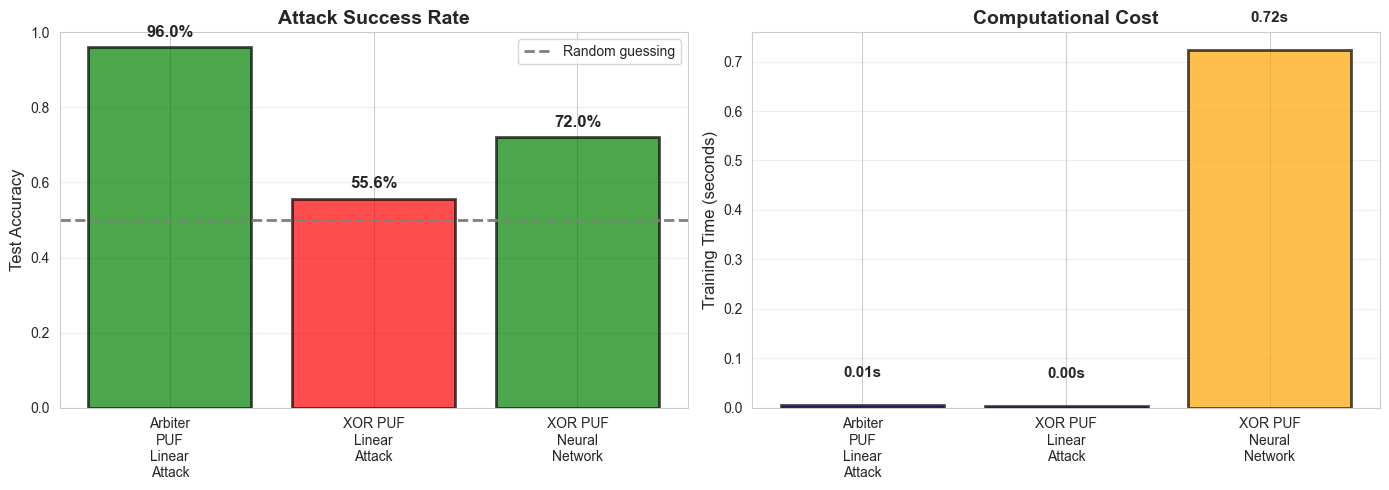


KEY INSIGHT:
XOR PUFs defend against simple linear attacks,
but neural networks can still break them with enough training data.


In [5]:
# create comparison visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# accuracy comparison
puf_types = ['Arbiter\nPUF', 'XOR PUF', 'XOR PUF']
attacks = ['Linear\nAttack', 'Linear\nAttack', 'Neural\nNetwork']
accuracies = [test_acc, test_acc_xor, test_acc_nn]
colors = ['green', 'red', 'green']

bars = axes[0].bar(range(3), accuracies, color=colors, alpha=0.7, 
                    edgecolor='black', linewidth=2)
axes[0].axhline(y=0.5, color='gray', linestyle='--', 
                label='Random guessing', linewidth=2)
axes[0].set_ylabel('Test Accuracy', fontsize=12)
axes[0].set_title('Attack Success Rate', fontsize=14, fontweight='bold')
axes[0].set_xticks(range(3))
axes[0].set_xticklabels([f"{p}\n{a}" for p, a in zip(puf_types, attacks)])
axes[0].set_ylim([0, 1])
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

for bar, acc in zip(bars, accuracies):
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height + 0.02,
                f'{acc:.1%}', ha='center', va='bottom', 
                fontsize=12, fontweight='bold')

# training time comparison
times = [lr_attack.training_time, lr_attack_xor.training_time, 
         mlp_attack.training_time]
bars2 = axes[1].bar(range(3), times, color=['blue', 'blue', 'orange'], 
                     alpha=0.7, edgecolor='black', linewidth=2)
axes[1].set_ylabel('Training Time (seconds)', fontsize=12)
axes[1].set_title('Computational Cost', fontsize=14, fontweight='bold')
axes[1].set_xticks(range(3))
axes[1].set_xticklabels([f"{p}\n{a}" for p, a in zip(puf_types, attacks)])
axes[1].grid(True, alpha=0.3, axis='y')

for bar, t in zip(bars2, times):
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height + 0.05,
                f'{t:.2f}s', ha='center', va='bottom', 
                fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("KEY INSIGHT:")
print("="*60)
print("XOR PUFs defend against simple linear attacks,")
print("but neural networks can still break them with enough training data.")
print("="*60)